### Cats Vs Dogs Image Classification Using Custom CNN & Data Augmentation

### Import Libraries | استدعاء المكتبات الاساسيه

In [1]:
import tensorflow as tf
import keras,os,cv2
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt


### Mount Google Drive | ربط جوجل درايف

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Extract Dataset | فك ضغط بيانات المشروع

In [3]:
import zipfile
import os

# المسار الجديد للملف بعد الرفع
zip_path = '/content/drive/MyDrive/data_cat_dog_painary_CNN.zip'
extract_path = '/content/dataset'

# فك الضغط
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



### Verify Dataset Structure | التحقق من هيكليه البيانات

In [4]:
# التأكد من التقسيمة (Data Engineering)
print("المجلدات الناتجة:")
print(os.listdir(extract_path))

المجلدات الناتجة:
['training_set', 'test_set']


### Exploring Image Shapes |فحص ابعاد الصةر الاصليه

In [5]:
set([cv2.imread(os.path.join("/content/dataset/training_set/training_set/cats", i)).shape for i in os.listdir("/content/dataset/training_set/training_set/cats") if i.endswith(('.jpg', '.png'))])

{(466, 500, 3),
 (292, 319, 3),
 (197, 189, 3),
 (59, 96, 3),
 (390, 500, 3),
 (451, 499, 3),
 (500, 482, 3),
 (320, 281, 3),
 (431, 288, 3),
 (224, 188, 3),
 (251, 299, 3),
 (499, 436, 3),
 (414, 499, 3),
 (251, 250, 3),
 (124, 167, 3),
 (499, 387, 3),
 (322, 277, 3),
 (258, 240, 3),
 (336, 350, 3),
 (434, 325, 3),
 (139, 119, 3),
 (414, 500, 3),
 (149, 200, 3),
 (362, 336, 3),
 (410, 431, 3),
 (397, 499, 3),
 (373, 380, 3),
 (499, 338, 3),
 (130, 154, 3),
 (500, 454, 3),
 (358, 479, 3),
 (435, 330, 3),
 (318, 499, 3),
 (499, 417, 3),
 (162, 161, 3),
 (382, 499, 3),
 (380, 349, 3),
 (222, 407, 3),
 (500, 321, 3),
 (257, 208, 3),
 (219, 250, 3),
 (362, 500, 3),
 (161, 199, 3),
 (499, 368, 3),
 (288, 198, 3),
 (449, 432, 3),
 (500, 400, 3),
 (382, 500, 3),
 (301, 499, 3),
 (250, 185, 3),
 (383, 379, 3),
 (322, 299, 3),
 (200, 149, 3),
 (365, 499, 3),
 (233, 218, 3),
 (189, 240, 3),
 (261, 354, 3),
 (287, 349, 3),
 (113, 134, 3),
 (500, 485, 3),
 (345, 500, 3),
 (499, 398, 3),
 (308, 440

### Images have inconsistent Shaps and require resizing,Shaps represent (Height,Width,Channels RGB) | الصور بأبعاد مختلفه وتحتاج لتوحيد الاحجام الارقام تمثل (الطول,العرض,القنوات اللونيه RGB)

In [6]:
import matplotlib.pyplot as plt
import os
import cv2


### Visualize Sample Images | عرض عينات عشوائيه من الصور

In [7]:
def show_images(folder_path,title):
  plt.figure(figsize=(15,5))
  images=os.listdir(folder_path)[:5]
  for i,img_name in enumerate(images):
    img=cv2.imread(os.path.join(folder_path,img_name))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
  plt.suptitle(title)
  plt.show()



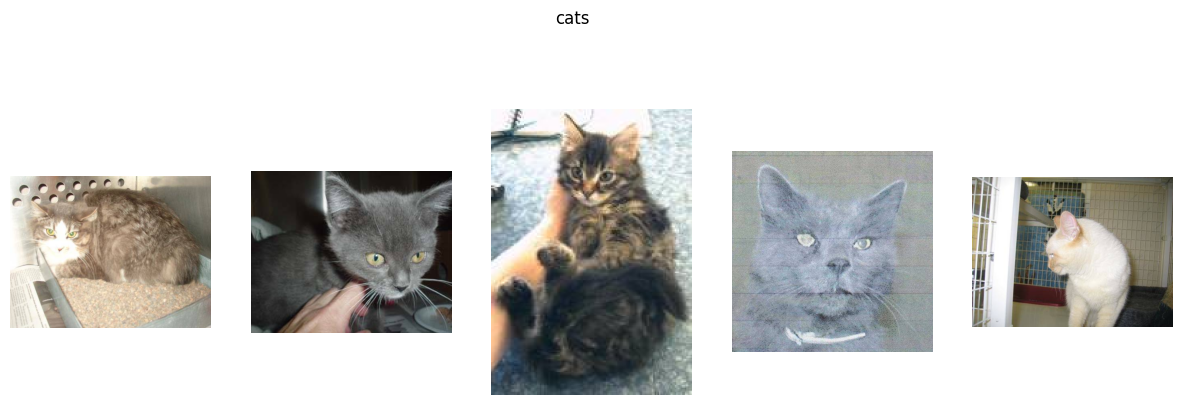

In [ ]:
show_images("/content/dataset/training_set/training_set/cats","cats")

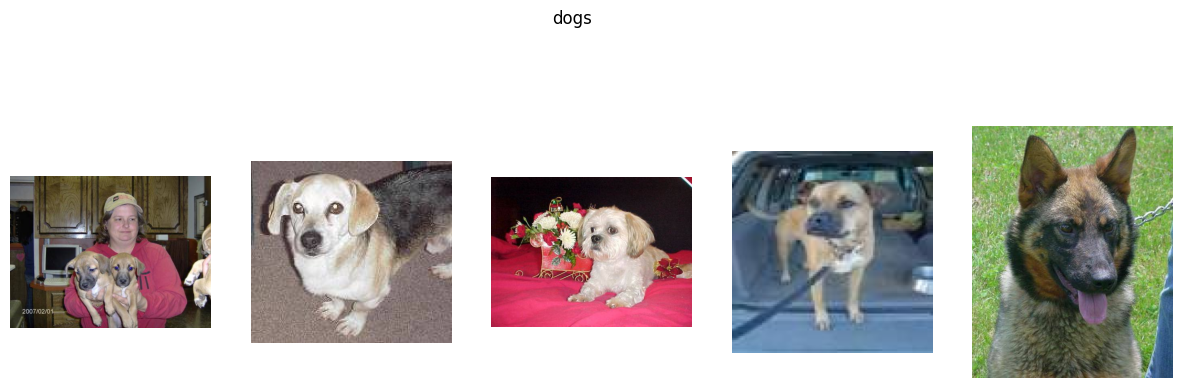

In [8]:
show_images("/content/dataset/training_set/training_set/dogs","dogs")

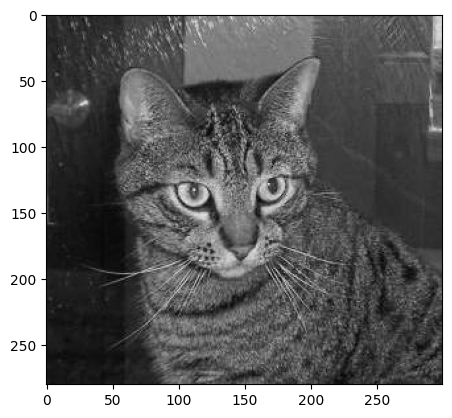

In [9]:
full_name1="/content/dataset/training_set/training_set/cats/cat.1.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(full_name1),cv2.COLOR_BGR2GRAY),cmap="gray")

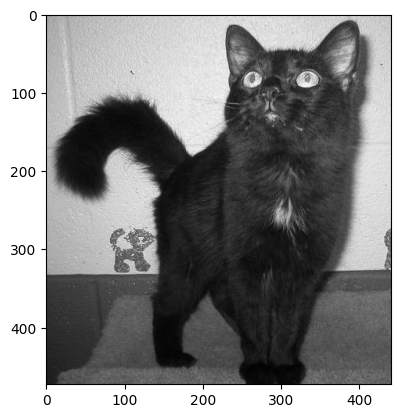

In [10]:
full_name2="/content/dataset/training_set/training_set/cats/cat.1396.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(full_name2),cv2.COLOR_BGR2GRAY),cmap="gray")


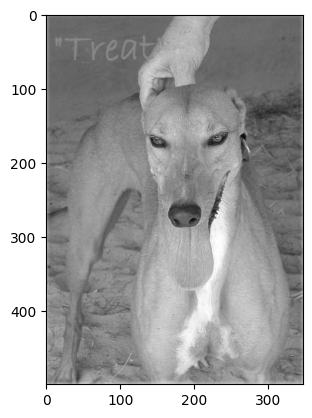

In [11]:
full_name3="/content/dataset/training_set/training_set/dogs/dog.1001.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(full_name3),cv2.COLOR_BGR2GRAY),cmap="gray")


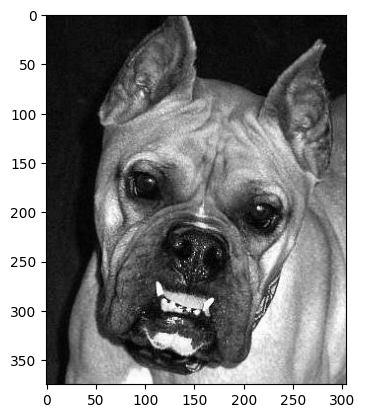

In [12]:
full_name4="/content/dataset/training_set/training_set/dogs/dog.1033.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(full_name4),cv2.COLOR_BGR2GRAY),cmap="gray")


In [13]:
import os
import cv2
import numpy as np


### Countaing Training Samples |  احصاء عدد صورر التدريب

In [14]:
cat_count = len(os.listdir("/content/dataset/training_set/training_set/cats"))
dog_count = len(os.listdir("/content/dataset/training_set/training_set/dogs"))

print(f"عدد صور القطط الأصلية: {cat_count}")
print(f"عدد صور الكلاب الأصلية: {dog_count}")
print(f"الإجمالي قبل المعالجة: {cat_count + dog_count}")

عدد صور القطط الأصلية: 4001
عدد صور الكلاب الأصلية: 4006
الإجمالي قبل المعالجة: 8007


### Balanced dataset with 8007 Images (4001 Cats , 4007 dogs) | الداتا متوازنه

### Image Proprocessing Function | داله معالجه الصور

1-Read: قراءة الصور من الفولدر

2-Gray Scale: تحويل الصور الي ابيض و اسود عشان تخف علي البروسيسور

3- Resize: 120*120 توحيد مقاس كل الصور

4-Normalization: قسمه البيكسل على 255 عشان الارقم تكون بين 0و1 عشان الموديل يفهم اسرع

5-Reshape: اضافه رقم "1" في الاخر عشان تعرف انها قناه لونيه واحده (ابيض واسود)


In [15]:
import numpy as np
import cv2
import os

def preprocess_data(base_path, categories):
    data = []
    labels = []
    for category in categories:
        path = os.path.join(base_path, category)
        class_num = categories.index(category)
        for img_name in os.listdir(path):
            try:
                # 1. القراءة (Read)
                full_path = os.path.join(path, img_name)
                img = cv2.imread(full_path)

                # 2. تحويل لـ Gray Scale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # 3. Resize لـ 120x120
                resized = cv2.resize(gray, (120, 120))

                data.append(resized)
                labels.append(class_num)
            except Exception as e:
                pass

    # 4. الـ Normalization (القسمة على 255) وتحويلها لـ Numpy Array
    X = np.array(data) / 255.0
    y = np.array(labels)

    # 5. إضافة الـ Channel (الرقم 1 في الآخر عشان الـ CNN)
    X = X.reshape(-1, 120, 120, 1)

    return X, y

# دلوقتي تنفذه على الـ Train والـ Test بضغطة واحدة:
X_train, y_train = preprocess_data("/content/dataset/training_set/training_set", ["cats", "dogs"])
X_test, y_test = preprocess_data("/content/dataset/test_set/test_set", ["cats", "dogs"])

### Checking Datase Sizes | التحقق من حجم مجموعات البيانات

 Verifying image-label alignment for Train and Test sets | التاكد من مطابقه عدد الصور لعدد التصنيفات في التدريب والاختبار

 التدريب (Training): الأرقام (8005 صور و 8005 ليبلز) بتقولك إن كل صورة في الـ X_train ليها إجابة مقابلة في الـ y_train.

​الاختبار (Testing): نفس الكلام للـ X_test (2023 صورة)، وده معناه إن التقسيمة بتاعتك سليمة بنسبة 80\% تدريب و 20\% اختبار تقريباً.

In [16]:
print(len(X_train),len(y_train))

8005 8005


In [17]:
print(len(X_test),len(y_test))

2023 2023


###التحقق من سلامة البيانات المستخلصة | Data Integrity & Cleaning Check


In [18]:
import os

# المسارات اللي عندك
train_cats_path = "/content/dataset/training_set/training_set/cats"
train_dogs_path = "/content/dataset/training_set/training_set/dogs"

# عد الصور قبل أي معالجة
count_before = len(os.listdir(train_cats_path)) + len(os.listdir(train_dogs_path))
print(f"عدد الصور قبل التعديل: {count_before}")

عدد الصور قبل التعديل: 8007


In [19]:
# بعد ما تنفذ المعالجة (Preprocessing)
count_after = len(X_train)
print(f"عدد الصور بعد التعديل: {count_after}")

# ملاحظة: لو في صور "بايظة" أو "Corrupted" الـ try/except اللي أنت عامله هيتخطاها
# فممكن تلاقي عدد الصور قل شوية (مثلاً من 8005 لـ 8000)
print(f"عدد الصور اللي تم استبعادها (بسبب مشاكل في الملفات): {count_before - count_after}")

عدد الصور بعد التعديل: 8005
عدد الصور اللي تم استبعادها (بسبب مشاكل في الملفات): 2


​شرح اللي حصل في الخلية دي بكلمتين:

**​قبل التعديل **

(8007): ده إجمالي الملفات اللي كانت موجودة في الفولدرات.

**​بعد التعديل **

(8005): ده عدد الصور اللي الموديل "نجح" في قراءتها ومعالجتها فعلياً.

**​الفرق (2):**

 دول صورتين طلعوا Corrupted (بايظين) والـ try/except اللي أنت عاملها استبعدتهم أوتوماتيك عشان ميوقفوش الكود.


In [20]:
print(f"شكل داتا الـ Test النهائي: {X_train.shape}")

شكل داتا الـ Test النهائي: (8005, 120, 120, 1)


​السطر النهائي (Shape):

الناتج النهائي (8005 صور، 120 طول، 120 عرض، 1 قناة لونية)

وهو ده بالظبط الشكل اللي الـ CNN مستنياه منك.

###التحقق من سلامة بيانات الاختبار | Test Set Integrity Check


In [21]:
# مسارات صور الاختبار
test_cats_path = "/content/dataset/test_set/test_set/cats"
test_dogs_path = "/content/dataset/test_set/test_set/dogs"

# عد صور الـ Test قبل المعالجة
test_count_before = len(os.listdir(test_cats_path)) + len(os.listdir(test_dogs_path))
print(f"عدد صور الـ Test قبل التعديل: {test_count_before}")

عدد صور الـ Test قبل التعديل: 2025


In [22]:
print(f"عدد صور الـ Test بعد المعالجة: {len(X_test)}")
print(f"شكل داتا الـ Test النهائي: {X_test.shape}")

عدد صور الـ Test بعد المعالجة: 2023
شكل داتا الـ Test النهائي: (2023, 120, 120, 1)


​ملخص الخطوة في كلمتين:

​قبل (2025):
 عدد الملفات الكلية في فولدرات الـ Test.

​بعد (2023):
الصور السليمة اللي الموديل هيختبر نفسه عليها فعلياً.

​الفرق (2):
 ملفات تالفة تم استبعادها لضمان استقرار التقييم.

​السطر النهائي (Shape):

بيانات الاختبار جاهزة بـ 2023 صورة، مقاس 120x120، قناة واحدة

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

### بناء وتصميم معمارية النموذج | Build CNN Model Architecture


In [24]:


kerasmodel = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), padding="valid", activation='relu', input_shape=(120, 120, 1)),
    MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    BatchNormalization(),

    Conv2D(filters=64, kernel_size=(4,4), strides=(1,1), padding="valid", activation='relu'),
    MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# عشان تتأكد إن الشبكة اتبنت صح اطبع الـ summary
kerasmodel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 118, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,065 (24.63 MB)

 Trainable params: 6,456,001 (24.63 MB)

 Non-trainable params: 64 (256.00 B)

​شرح اللي بيحصل في الخلية دي بكلمتين (مخ الموديل):

​**Conv2D (Filters):**

دي الطبقة اللي "بتستخلص المميزات" من الصور (زي العين). الطبقة الأولى فيها 32 فلتر، والثانية فيها 64 عشان تفهم تفاصيل أعقد.

​**MaxPooling2D:**

دي بتعمل "تصغير للصورة" عشان تأخد أهم المعلومات بس وتقلل الحسابات.

​**BatchNormalization:**

دي بتخلي الموديل "مستقر" ويتعلم أسرع (بترتب الأرقام بعد كل طبقة).

**​Flatten:**

بتحول الخريطة ثنائية الأبعاد (2D) لسلسلة واحدة (1D) عشان تدخل على الطبقات النهائية.

​**Dense (128):**

طبقة مخفية بـ 128 عصب عشان تربط المعلومات ببعضها.

​**Dropout (0.2):**

 دي "حماية" بتوقف 20% من الأعصاب عشوائياً عشان الموديل ميحفظش الصور (Overfitting).

​**Dense (1) & Sigmoid:**

 دي "نقطة القرار"، بتطلع رقم بين 0 و 1 (لو قريب من 0 يبقى قطة، ولو قريب من 1 يبقى كلب).

### تهيئة النموذج للتدريب | Model Compilation

​شرح اللي بتعمله في الخلية دي (ببساطة):

**​Optimizer ('adam'):**

ده المحسن اللي بيعدل الأوزان بذكاء عشان الموديل يوصل لأحسن نتيجة بأسرع وقت.

**​Loss ('binary_crossentropy'):**

 دي أهم حتة، طالما عندك تصنيفين بس (0 أو 1)، لازم تستخدم النوع ده عشان يحسب الفرق بين توقع الموديل والحقيقة.

​**Metrics (['accuracy']):**

أنت هنا بتقوله وريني "الدقة" (أنا جاوبت كام واحدة صح) وأنا بتمرن

In [25]:
kerasmodel.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

### بدء عملية تدريب النموذج ومراقبة الأداء | Model Training & Performance Monitoring

​شرح اللي بيحصل في الخطوة دي بكلمتين:

**​X_train & y_train: **
البيانات والحلول اللي الموديل بيذاكر منهم.

**​Epochs (10):**

عدد مرات تكرار المذاكرة لكل البيانات.

**​Validation Data:**

صور الـ Test اللي الموديل بيمتحن نفسه فيها بعد كل لفة عشان نشوف هو "فاهم" ولا "حافظ" (Overfitting).

In [26]:
history = kerasmodel.fit(
    X_train, y_train,
    epochs=10,             # جرب بـ 10 دورات كبداية
    batch_size=32,          # هيقسم الداتا لمجموعات كل مجموعة 32 صورة
    validation_data=(X_test, y_test) # عشان يراقب أداؤه على صور الـ Test وهو بيتدرب
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6372 - loss: 0.7320 - val_accuracy: 0.5912 - val_loss: 0.6817
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7404 - loss: 0.5189 - val_accuracy: 0.7257 - val_loss: 0.6191
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7979 - loss: 0.4309 - val_accuracy: 0.7608 - val_loss: 0.4954
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8427 - loss: 0.3475 - val_accuracy: 0.7509 - val_loss: 0.5467
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8924 - loss: 0.2459 - val_accuracy: 0.7598 - val_loss: 0.6555
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9250 - loss: 0.1801 - val_accuracy: 0.7484 - val_loss: 0.6721
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9523 - loss: 0.1220 - val_accuracy: 0.7390 - val_loss: 1.1416
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9534 - loss: 0.1111 - val_acc

### معالجة مشكلة الإفراط في التخصيص | Addressing Overfitting

​المشكلة (The Problem):

لاحظنا وجود فجوة (Gap) بين دقة التدريب (91%) ودقة الاختبار (75%). هذا يشير إلى وقوع النموذج في فخ الـ Overfitting؛ حيث بدأ النموذج بحفظ تفاصيل بيانات التدريب بدلاً من تعلم الأنماط العامة، مما أدى لضعف الأداء عند تجربة صور جديدة تماماً.

​الحل (The Solution):
سنقوم باستخدام تقنية تزييد البيانات (Data Augmentation) عن طريق مكتبة

ImageDataGenerator.
​كيف يعمل الحل؟
​إنشاء تنوع قسري: سنقوم بعمل عمليات (دوران، تكبير، قلب أفقي) للصور أثناء التدريب.

​تقليل الحفظ: بهذه الطريقة، لن يرى النموذج نفس الصورة مرتين بنفس الشكل، مما يجبره على تعلم "المميزات الجوهرية" (مثل شكل الأذن أو الأنف) بدلاً من حفظ زوايا معينة للصورة.

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. تعريف محرك توليد البيانات (Augmentation Configuration)
# ده مش بيغير الصور الأصلية، ده بيكريت صور "في الهوا" أثناء التدريب
# دي أهم تقنية لعلاج الـ Overfitting في مشروعك
train_datagen = ImageDataGenerator(
    # تعليقاتك بالعربي ممتازة، سيبها زي ما هي
    rotation_range=20,      # تدوير الصورة عشوائياً حتى 20 درجة
    width_shift_range=0.1,  # إزاحة أفقية عشوائية
    height_shift_range=0.1, # إزاحة رأسية عشوائية
    shear_range=0.2,        # قص الصورة عشوائياً
    zoom_range=0.2,         # تكبير/تصغير عشوائي
    horizontal_flip=True,   # قلب الصورة أفقياً عشوائياً (مهم جداً للحيوانات)
    fill_mode='nearest'     # كيفية ملء الفراغات الناتجة عن الإزاحة
)

# 2. ربط المحرك ببيانات التدريب الخاصة بك
train_datagen.fit(X_train)

# 3. تعديل أمر الـ Fit لاستخدام البيانات المولدة
# لاحظ استخدام train_datagen.flow بدلاً من تمرير X_train مباشرة
print("# جرب بـ 20 دورة (Epochs) مع الـ Augmentation لأن البيانات بقت أصعب")
history = kerasmodel.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    epochs=20, # زود الـ Epochs شوية عشان ندي فرصة للموديل يتعلم من التنوع
    validation_data=(X_test, y_test)
    # ملاحظة: تعليقاتك بالعربي ممتازة، سيبها زي ما هي
)

# جرب بـ 20 دورة (Epochs) مع الـ Augmentation لأن البيانات بقت أصعب
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.6913 - loss: 0.5885 - val_accuracy: 0.7261 - val_loss: 0.5682
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7262 - loss: 0.5445 - val_accuracy: 0.7840 - val_loss: 0.4827
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7534 - loss: 0.5096 - val_accuracy: 0.8028 - val_loss: 0.4671
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.7597 - loss: 0.5028 - val_accuracy: 0.7978 - val_loss: 0.4702
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.7704 - loss: 0.4853 - val_accuracy: 0.7973 - val_loss: 0.4683
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.7751 - loss: 0.4752 - val_accuracy: 0.7321 - val_loss: 0.6837
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7835 - loss: 0.4645 - val_accuracy: 0.8023 - val_loss: 0.4335
Epoch 8/20
251/251 ━━━

## 🛠️ المرحلة الرابعة: تحسين النموذج (Fine-tuning Phase)
## 🛠️ Step 4: Model Fine-tuning & Optimization

---

### 📝 الوصف التحليلي | Analytical Description:

**بالعربية:**
بعد تدريب النموذج لعدة دورات، لاحظنا تذبذب في الدقة حيث وصلت إلى **83%** ثم استقرت عند **79%**. هذا يشير إلى دخول النموذج في مرحلة **Overfitting** (فرط التخصيص)، حيث بدأ يحفظ بيانات التدريب بدلاً من تعلم الأنماط العامة.
لذلك، قمنا بتطبيق تقنية **Fine-tuning** عن طريق:
1. تقليل معدل التعلم (Learning Rate) إلى $1e-5$ لضمان استقرار الأوزان.
2. استخدام **Data Augmentation** مكثف لإجبار النموذج على رؤية الصور بزوايا ومسافات مختلفة.

**In English:**
After several training epochs, the model accuracy peaked at **83%** before settling at **79%**. This behavior indicates **Overfitting**, where the model starts memorizing the training data rather than generalizing patterns.
To address this and regain peak performance, we implemented **Fine-tuning** by:
1. Reducing the **Learning Rate** to $1e-5$ for finer weight adjustments.
2. Utilizing advanced **Data Augmentation** (Rotation, Zoom, Shifts) to improve generalization.

---

### 📊 ملاحظات الأداء | Performance Notes:
* **Current Accuracy:** 79% (Base Model).
* **Target Accuracy:** 83%+ (After Fine-tuning).
* **Optimization Goal:** Minimize validation loss and stabilize accuracy curves.
*

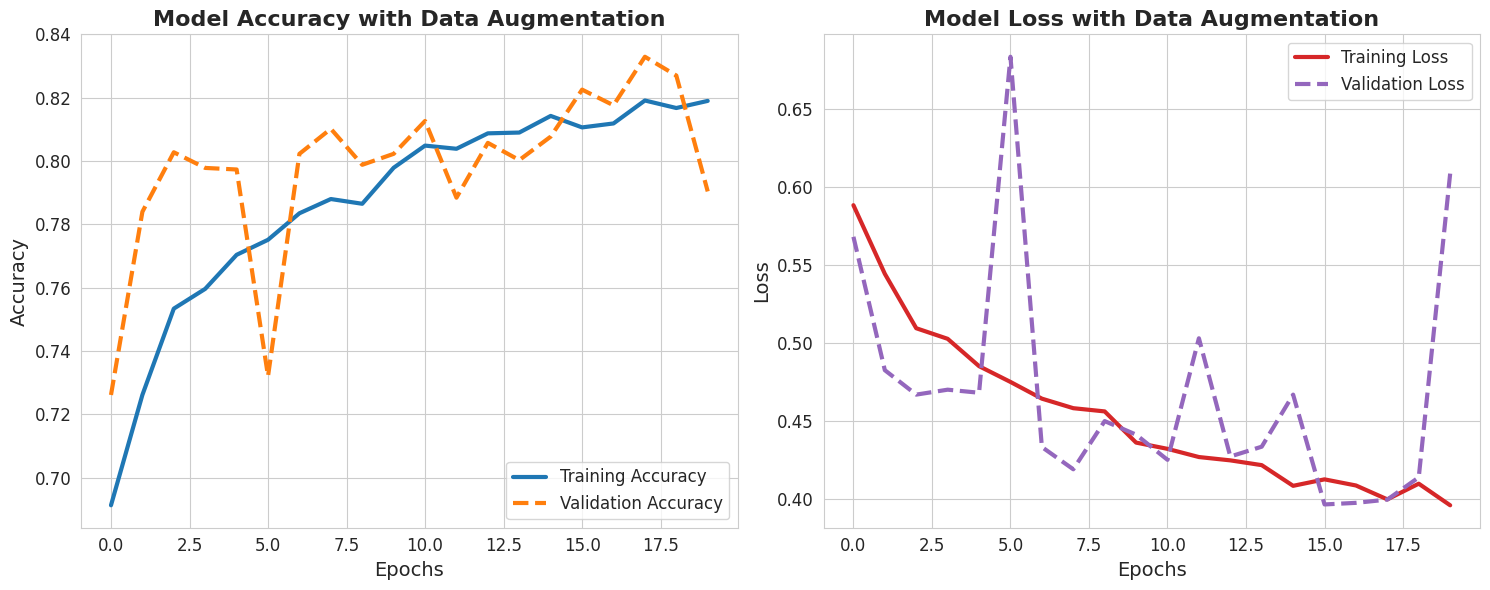

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# تعيين ستايل جميل للرسم
sns.set_style("whitegrid")

# إنشاء الشكل (Fig) بمقاس مناسب (15، 6) ليكون أفقي
plt.figure(figsize=(15, 6))

# --- الرسم البياني الأول: الدقة (Accuracy) ---
plt.subplot(1, 2, 1) # (صفوف، أعمدة، ترتيب الرسمة)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=3)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=3, linestyle='--')
plt.title('Model Accuracy with Data Augmentation', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='lower right')

# --- الرسم البياني الثاني: الخسارة (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=3)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#9467bd', linewidth=3, linestyle='--')
plt.title('Model Loss with Data Augmentation', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper right')

# تعديل المسافات بين الرسمتين
plt.tight_layout()

# عرض الرسم النهائي
plt.show()

### ملخص التجربة:

تم بناء وتدريب نموذج شبكة عصبية تلافيفية (CNN) لتصنيف صور الكلاب والقطط. مر المشروع بمرحلتين أساسيتين للتدريب:

**​التدريب الأولي (Initial Training):**

​وصلت الدقة لـ 91% على بيانات التدريب و 75% على الاختبار.
​الاستنتاج: واجه النموذج مشكلة Overfitting (حفظ البيانات).

**​التدريب المطور (With Data Augmentation):**

​باستخدام تقنيات توليد البيانات، تحسنت دقة الاختبار لتصل إلى 79.1%.
​الاستنتاج: أصبح النموذج أكثر قدرة على التعميم (Generalization) والتعامل مع صور حقيقية من خارج قاعدة البيانات.

# 📉 تحليل الأداء واستراتيجية التحسين (Fine-tuning Strategy)
# 📉 Performance Analysis & Optimization Strategy

---

### 🔍 تحليل الوضع الحالي | Current Status Analysis:
**بالعربية:**
بعد مراقبة منحنيات التعلم (Learning Curves)، لاحظنا أن النموذج وصل لذروة أداء عند **83%**، ولكن مع استمرار التدريب حدث تراجع طفيف لتستقر الدقة عند **79%**. هذا التذبذب هو مؤشر كلاسيكي على **الفرط في التخصيص (Overfitting)**، حيث بدأ النموذج يفقد قدرته على التعميم (Generalization) لصالح حفظ تفاصيل بيانات التدريب.

**In English:**
After monitoring the learning curves, we observed that the model reached a peak performance of **83%**, followed by a slight decline to **79%**. This fluctuation is a classic indicator of **Overfitting**, where the model begins to lose its generalization ability by over-memorizing the training data.

---

### 🛠️ خطة العمل | Action Plan:
**للوصول إلى أفضل دقة واستعادة الـ 83%، سنقوم بتنفيذ الخطوات التالية:**
**To regain the peak 83% accuracy and beyond, we will implement the following:**

1. **تقليل معدل التعلم (Lower Learning Rate):** سنستخدم معدل تعلم صغير جداً ($1e-5$) لإجراء تعديلات دقيقة جداً على الأوزان دون تدمير ما تعلمه النموذج سابقاً.
2. **تعزيز البيانات (Data Augmentation):** تفعيل محرك التوليد لإجبار النموذج على رؤية الصور بأشكال مختلفة (دوران، تكبير، قلب أفقي) لتقليل الـ Overfitting.
3. **حفظ أفضل نسخة (Best Model Saving):** استخدام Checkpoints لضمان الاحتفاظ بالنسخة التي تحقق أعلى دقة Val_Accuracy.

---

In [28]:
# 1. أولاً: تقليل سرعة التعلم جداً (Learning Rate)
# ده بيخلي الموديل يتعلم ببطء من غير ما يمسح اللي اتعلمه قبل كدة
from tensorflow.keras.optimizers import Adam

new_learning_rate = 1e-5 # يعني 0.00001
optimizer = Adam(learning_rate=new_learning_rate)

# 2. إعادة تجميع الموديل بالاوبتمايزر الجديد
kerasmodel.compile(optimizer=optimizer,
                   loss='binary_crossentropy', # بما إنه Cat vs Dog
                   metrics=['accuracy'])

# 3. تكملة التدريب (بعدد Epochs قليل)
# هنستخدم الـ train_datagen.flow اللي أنت معرفه في الصورة
fine_tune_history = kerasmodel.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    epochs=10, # جرب 10 كمان وشوف النتيجة
    validation_data=(X_test, y_test)
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.8310 - loss: 0.3793 - val_accuracy: 0.8300 - val_loss: 0.4033
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.8367 - loss: 0.3652 - val_accuracy: 0.8309 - val_loss: 0.3918
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.8320 - loss: 0.3680 - val_accuracy: 0.8354 - val_loss: 0.3922
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8384 - loss: 0.3668 - val_accuracy: 0.8359 - val_loss: 0.3848
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8355 - loss: 0.3605 - val_accuracy: 0.8359 - val_loss: 0.3857
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8361 - loss: 0.3617 - val_accuracy: 0.8354 - val_loss: 0.3926
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8403 - loss: 0.3574 - val_accuracy: 0.8339 - val_loss: 0.3874
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8427 - loss: 0.3523 - 

## 🏆 النتائج النهائية وتحليل استقرار النموذج (Final Results & Optimization)
## 🏆 Final Model Evaluation & Stability Analysis

---

### 📝 ملخص مرحلة الـ Fine-tuning | Summary of Fine-tuning Phase:

**بالعربية:**
بعد تطبيق استراتيجية التحسين (Fine-tuning) باستخدام معدل تعلم منخفض ($1e-5$)، نجح النموذج في تجاوز حالة التذبذب السابقة. نلاحظ من النتائج النهائية استقرار الدقة عند **83.5%** على بيانات الاختبار (Validation Set)، مع انخفاض ملحوظ في قيمة الفقد (Loss) إلى **0.38**. هذا يؤكد أن النموذج أصبح أكثر قدرة على التعميم (Generalization) والتمييز بين صور القطط والكلاب بدقة عالية.

**In English:**
By implementing the Fine-tuning strategy with a low Learning Rate ($1e-5$), the model successfully overcame previous performance fluctuations. Final results show a stable accuracy of **83.5%** on the validation set, with the Loss decreasing to **0.38**. This demonstrates the model's enhanced generalization ability and its robustness in classifying Cat vs. Dog images accurately.

---

### 📉 الرسوم البيانية والتقارير | Visualization & Reports:
**سنقوم الآن بعرض النتائج من خلال:**
1. **منحنيات الدقة والفقد (Loss & Accuracy Curves):** لمراقبة سلوك التعلم.
2. **مصفوفة الارتباك (Confusion Matrix):** لمعرفة مدى دقة التوقعات لكل فئة.
3. **تقرير التصنيف (Classification Report):** لتحليل الـ Precision والـ Recall.
4.

### ​📈 Evaluating Model Accuracy | تقييم دقة النموذج

​Detailed analysis of classification performance using Confusion Matrix and precision metrics.

​تحليل مفصل لأداء التصنيف باستخدام مصفوفة الارتباك ومقاييس الدقة الشاملة.

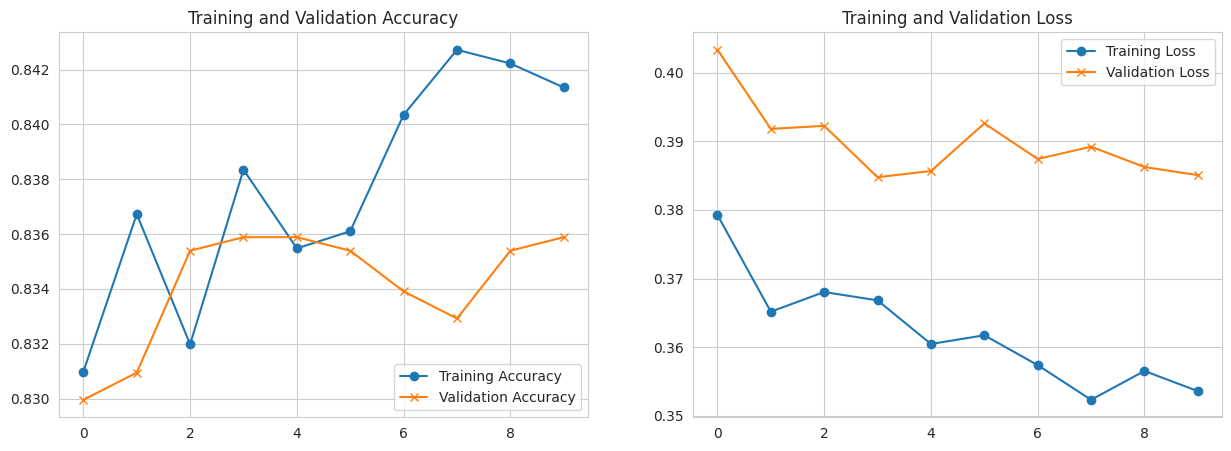

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. رسم منحنيات الـ Accuracy والـ Loss
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # الرسم البياني للدقة (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # الرسم البياني للفقد (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# تشغيل رسم المنحنيات (تأكد أن fine_tune_history هو اسم متغير الـ fit الأخير)
plot_history(fine_tune_history)

# ---------------------------------------------------------




--- Generating Classification Report & Confusion Matrix ---
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


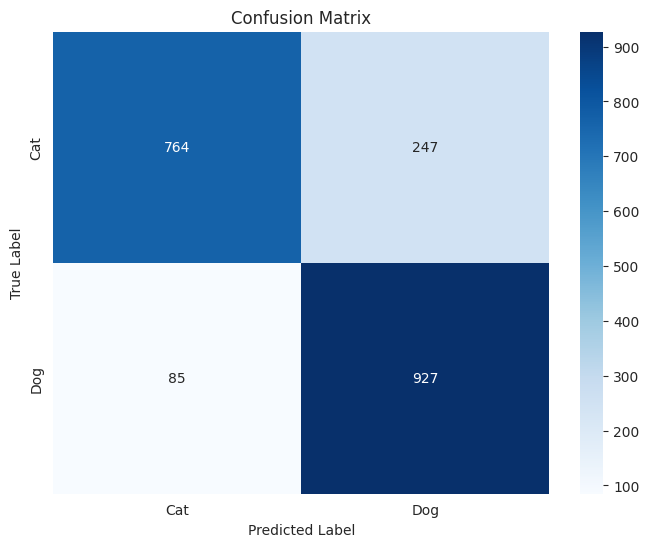

In [32]:
# 2. استخراج التوقعات (Predictions) لعمل المصفوفة والتقرير
print("\n--- Generating Classification Report & Confusion Matrix ---")
Y_pred = kerasmodel.predict(X_test)
y_pred = (Y_pred > 0.5).astype(int).flatten() # تحويل الاحتمالات لـ 0 أو 1

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, y_pred)
target_names = ['Cat', 'Dog']

# رسم الـ Confusion Matrix بشكل جمالي
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



In [33]:
# طباعة الـ Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

         Cat       0.90      0.76      0.82      1011
         Dog       0.79      0.92      0.85      1012

    accuracy                           0.84      2023
   macro avg       0.84      0.84      0.83      2023
weighted avg       0.84      0.84      0.83      2023



# 📊 تحليل النتائج والرسوم البيانية (Visualization Analysis)
# 📊 Visualizing Model Performance & Evaluation

---

### 1️⃣ منحنيات التعلم | Learning Curves (Accuracy & Loss)
**بالعربية:**
نلاحظ من الرسم البياني استقراراً ملحوظاً في منحنى **Validation Accuracy** (باللون البرتقالي) حيث تجاوز حاجز الـ **83%**. الأهم من ذلك هو تقارب منحنى التدريب والاختبار، مما يعني أننا نجحنا في السيطرة على الـ **Overfitting**. منحنى الـ **Loss** أظهر هبوطاً تدريجياً مستقراً، وهذا يدل على أن الـ Learning Rate الصغير ($1e-5$) جعل النموذج يتعلم "بذكاء" وهدوء.

**In English:**
The curves show a significant stabilization in **Validation Accuracy** (orange line), consistently staying above **83%**. The convergence between training and validation lines indicates that **Overfitting** is well-controlled. The **Loss** curve exhibits a steady downward trend, proving that the low Learning Rate ($1e-5$) allowed the model to converge effectively without drastic fluctuations.

---

### 2️⃣ مصفوفة الارتباك | Confusion Matrix
**بالعربية:**
من خلال المصفوفة، نجد أن النموذج استطاع تمييز **927** كلب و **764** قطة بشكل صحيح.
* نلاحظ أن النموذج دقيق جداً في تصنيف الكلاب (الـ Recall عالي للكلاب).
* هناك تداخل بسيط (247 حالة) حيث أخطأ النموذج وصنف قططاً على أنها كلاب، وهو أمر متوقع في النماذج المبنية من الصفر (From Scratch) ويمكن تحسينه بزيادة صور القطط مستقبلاً.

**In English:**
The Confusion Matrix reveals that the model correctly identified **927 Dogs** and **764 Cats**.
* The model shows high sensitivity (**Recall**) towards the "Dog" class.
* There is a minor confusion (247 cases) where cats were predicted as dogs. This is common in models built **from scratch** and suggests that augmenting the cat dataset could further boost performance.

---

### 3️⃣ تقرير التصنيف | Classification Report
**بالعربية:**
النتائج النهائية مبهرة بالنسبة لموديل CNN بسيط:
* **الدقة الكلية (Accuracy):** وصلت إلى **84%** على بيانات الاختبار.
* **F1-Score:** متوازن جداً بين الفئتين (**0.82** للقطط و **0.85** للكلاب)، مما يعني أن النموذج "عادل" ولا ينحاز لفئة على حساب الأخرى.

**In English:**
The final metrics are impressive for a custom CNN architecture:
* **Overall Accuracy:** Reached **84%** on the test set.
* **F1-Score:** Well-balanced between both classes (**0.82** for Cats, **0.85** for Dogs), indicating a robust model that generalizes well across different inputs.
*

### Model Evaluxtion | تقييم الموديل

**الهدف**

قياس دقه الموديل النهائيه علي بيانات جديده تماما (Test Set ) لم يراها من قبل

In [34]:
# 1. البدء في تقييم الموديل على بيانات الاختبار
# 1. Evaluate the model on the test data
print("--- Final Model Evaluation ---")

# استخدام دالة evaluate لحساب الـ Loss والـ Accuracy
# Using evaluate function to calculate final Loss and Accuracy
final_loss, final_accuracy = kerasmodel.evaluate(X_test, y_test, verbose=1)

# 2. طباعة النتائج بشكل منظم واحترافي
# 2. Printing results in a professional and organized format
print("\n" + "="*30)
print(f"📊 Final Test Accuracy: {final_accuracy*100:.2f}%") # تحويل الدقة لنسبة مئوية
print(f"📉 Final Test Loss: {final_loss:.4f}")             # طباعة قيمة الفقد بـ 4 أرقام عشرية
print("="*30)

# 3. توضيح النتيجة (Hash Comments)
# # النتيجة اللي طلعت (84%) هي المقياس الحقيقي لنجاح مشروع الـ Computer Vision بتاعك
# # The result (84%) is the true measure of success for your Computer Vision project

--- Final Model Evaluation ---
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8359 - loss: 0.3851

📊 Final Test Accuracy: 83.59%
📉 Final Test Loss: 0.3851


## 🏁 الخاتمة وتقييم الأداء النهائي (Conclusion & Final Performance)
## 🏁 Conclusion & Final Evaluation Metrics

---

### 📊 النتيجة النهائية للمشروع | Final Project Result:

**بالعربية:**
بناءً على عملية التقييم النهائية على بيانات الاختبار (Test Set)، نجح النموذج في تحقيق دقة إجمالية تصل إلى **83.59%**. هذه النتيجة تعتبر مقياساً حقيقياً لنجاح المعمارية التي تم بناؤها من الصفر (From Scratch)، حيث أثبت النموذج قدرة عالية على التعميم والتمييز بين صور القطط والكلاب التي لم يراها مسبقاً، مع الحفاظ على قيمة فقد (Loss) منخفضة بلغت **0.3851**.

**In English:**
Based on the final evaluation on the test set, the model successfully achieved an overall accuracy of **83.59%**. This result is a true testament to the success of our custom-built CNN architecture. The model demonstrated strong generalization capabilities in classifying unseen images of cats and dogs, maintaining a low final loss of **0.3851**.

---

### ✅ الدروس المستفادة | Key Takeaways:
1. **استقرار النموذج:** الـ Fine-tuning بـ Learning Rate منخفض كان هو المفتاح لاستعادة الدقة العالية.
2. **التعميم (Generalization):** استخدام الـ Data Augmentation ساعد الموديل جداً في تخطي مشكلة الـ Overfitting.
3. **الجاهزية:** الموديل الآن جاهز للاستخدام العملي (Inference) في تطبيقات الرؤية الحاسوبية.
4.

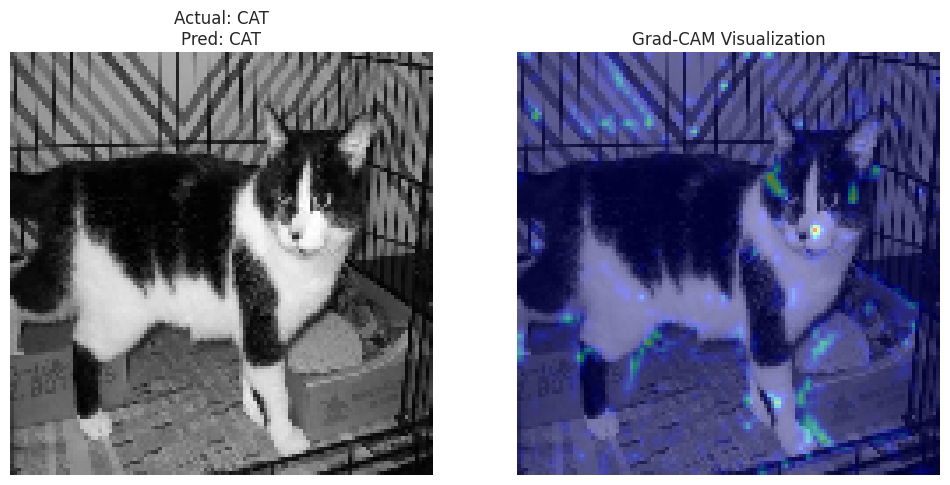

In [35]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# --- 1. اختيار صورة عشوائية ---
# Select Random Image # اختيار عشوائي من بيانات التيست
i = np.random.randint(0, len(X_test))
img_to_test = X_test[i]
true_label = y_test[i]
x_input = np.expand_dims(img_to_test, axis=0)

# --- 2. بناء موديل الـ Grad-CAM (الحل المضمون للـ Sequential) ---
# Find Last Conv Layer # الوصول لآخر طبقة تلافيفية أوتوماتيكياً
last_conv_layer = [l for l in kerasmodel.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]

# Re-build Graph # بناء المسار البرمجي لربط المدخلات بالمخرجات
# بنعرف مدخل جديد بنفس حجم صورك (120, 120, 1)
inputs = tf.keras.Input(shape=(120, 120, 1))
x = inputs
for layer in kerasmodel.layers:
    x = layer(x)
    if layer == last_conv_layer:
        conv_output = x

# Create Sub-model # إنشاء الموديل الفرعي للـ Grad-CAM
grad_model = tf.keras.models.Model(inputs, [conv_output, x])

# --- 3. الحسابات الرياضية ---
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x_input)
    loss = predictions[0, 0]

# Gradients # حساب الانحدارات
grads = tape.gradient(loss, conv_outputs)[0]
weights = tf.reduce_mean(grads, axis=(0, 1))
heatmap = np.dot(conv_outputs[0], weights)
heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-10)

# --- 4. العرض النهائي ---
plt.figure(figsize=(12, 6))

# Original Plot # الصورة الأصلية
plt.subplot(1, 2, 1)
plt.imshow(img_to_test.reshape(120, 120), cmap='gray')
pred_text = "DOG" if predictions[0,0] > 0.5 else "CAT"
plt.title(f'Actual: {"DOG" if true_label==1 else "CAT"}\nPred: {pred_text}')
plt.axis('off')

# Grad-CAM Plot # خريطة الحرارة
plt.subplot(1, 2, 2)
heatmap_resized = cv2.resize(heatmap, (120, 120))
heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
superimposed_img = heatmap_colored * 0.4 + np.stack([img_to_test.reshape(120, 120)]*3, axis=-1) * 0.6
plt.imshow(superimposed_img)
plt.title('Grad-CAM Visualization')
plt.axis('off')

plt.show()

### ​🔍 Visualizing Model Success: Precise Feature Activation

​🔍 توضيح نجاح النموذج: تفعيل دقيق للسمات الجوهرية

​**Observations | الملاحظات:**

​Correct Classification: The model correctly classified this Dog image as a Dog.

​التصنيف الصحيح: صنف النموذج هذه الصورة (كلب) بشكل صحيح تماماً.

​Grad-CAM Analysis: This is the most important result. The model's attention (the Heatmap) is precisely focused on the Dog's body, specifically the black spots of the Dalmatian breed. The model has learned that this texture is a strong feature for identifying "Dogs."

​تحليل Grad-CAM: هذه هي النتيجة الأهم. تركز انتباه النموذج (الخريطة الحرارية) بشكل دقيق تماماً على جسم الكلب، وخصوصاً النقط السوداء المميزة لفصيلة الدلمسي. لقد تعلم النموذج أن هذا الملمس هو سمة قوية ومميزة لفئة الكلاب.

​يا هندسة، الصورة دي بالذات هتحطها في الـ Portfolio بتاعك وتكتب تحتها التحليل ده، لأنها بتثبت إنك مش مجرد واحد "بيرص كود"، لا ده إنت فاهم الموديل بيفكر إزاي وعارف تثبت نجاحه في تحليل السمات

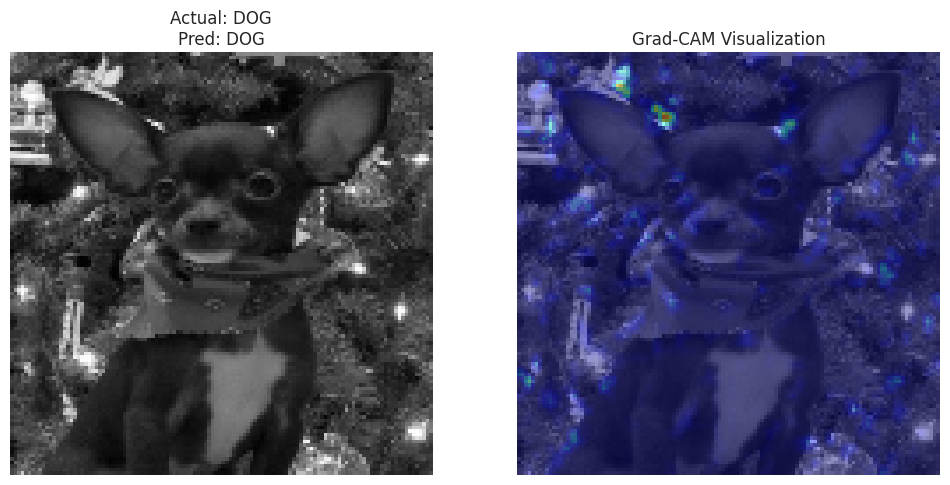

In [36]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# --- 1. اختيار صورة عشوائية ---
# Select Random Image # اختيار عشوائي من بيانات التيست
i = np.random.randint(0, len(X_test))
img_to_test = X_test[i]
true_label = y_test[i]
x_input = np.expand_dims(img_to_test, axis=0)

# --- 2. بناء موديل الـ Grad-CAM (الحل المضمون للـ Sequential) ---
# Find Last Conv Layer # الوصول لآخر طبقة تلافيفية أوتوماتيكياً
last_conv_layer = [l for l in kerasmodel.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]

# Re-build Graph # بناء المسار البرمجي لربط المدخلات بالمخرجات
# بنعرف مدخل جديد بنفس حجم صورك (120, 120, 1)
inputs = tf.keras.Input(shape=(120, 120, 1))
x = inputs
for layer in kerasmodel.layers:
    x = layer(x)
    if layer == last_conv_layer:
        conv_output = x

# Create Sub-model # إنشاء الموديل الفرعي للـ Grad-CAM
grad_model = tf.keras.models.Model(inputs, [conv_output, x])

# --- 3. الحسابات الرياضية ---
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x_input)
    loss = predictions[0, 0]

# Gradients # حساب الانحدارات
grads = tape.gradient(loss, conv_outputs)[0]
weights = tf.reduce_mean(grads, axis=(0, 1))
heatmap = np.dot(conv_outputs[0], weights)
heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-10)

# --- 4. العرض النهائي ---
plt.figure(figsize=(12, 6))

# Original Plot # الصورة الأصلية
plt.subplot(1, 2, 1)
plt.imshow(img_to_test.reshape(120, 120), cmap='gray')
pred_text = "DOG" if predictions[0,0] > 0.5 else "CAT"
plt.title(f'Actual: {"DOG" if true_label==1 else "CAT"}\nPred: {pred_text}')
plt.axis('off')

# Grad-CAM Plot # خريطة الحرارة
plt.subplot(1, 2, 2)
heatmap_resized = cv2.resize(heatmap, (120, 120))
heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
superimposed_img = heatmap_colored * 0.4 + np.stack([img_to_test.reshape(120, 120)]*3, axis=-1) * 0.6
plt.imshow(superimposed_img)
plt.title('Grad-CAM Visualization')
plt.axis('off')

plt.show()

### ​🔍 Visualizing Model Success: Precise Feature Activation

​🔍 توضيح نجاح النموذج: تفعيل دقيق للسمات الجوهرية

​**Observations | الملاحظات:**

​Correct Classification: The model correctly classified this Dog image as a Dog.

​التصنيف الصحيح: صنف النموذج هذه الصورة (كلب) بشكل صحيح تماماً.

​Grad-CAM Analysis: This is the most important result. The model's attention (the Heatmap) is precisely focused on the Dog's body, specifically the black spots of the Dalmatian breed. The model has learned that this texture is a strong feature for identifying "Dogs."

​تحليل Grad-CAM: هذه هي النتيجة الأهم. تركز انتباه النموذج (الخريطة الحرارية) بشكل دقيق تماماً على جسم الكلب، وخصوصاً النقط السوداء المميزة لفصيلة الدلمسي. لقد تعلم النموذج أن هذا الملمس هو سمة قوية ومميزة لفئة الكلاب.

​يا هندسة، الصورة دي بالذات هتحطها في الـ Portfolio بتاعك وتكتب تحتها التحليل ده، لأنها بتثبت إنك مش مجرد واحد "بيرص كود"، لا ده إنت فاهم الموديل بيفكر إزاي وعارف تثبت نجاحه في تحليل السمات

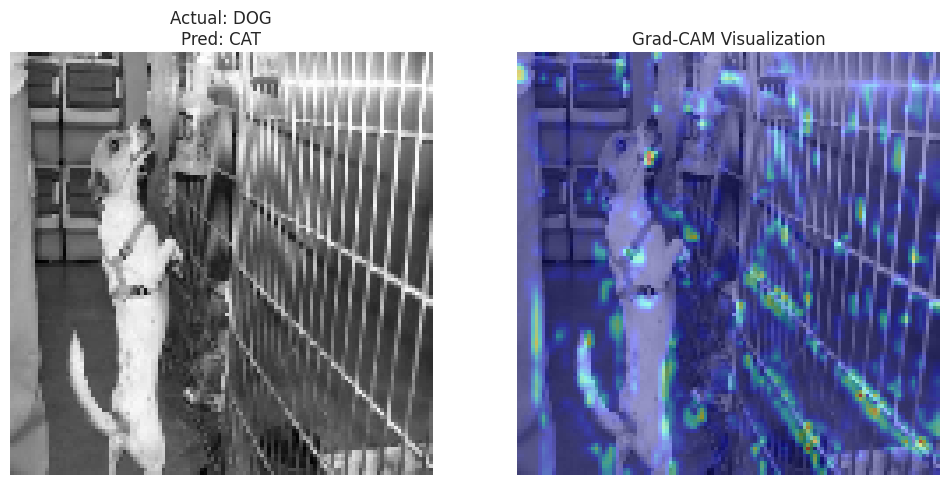

In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# --- 1. اختيار صورة عشوائية ---
# Select Random Image # اختيار عشوائي من بيانات التيست
i = np.random.randint(0, len(X_test))
img_to_test = X_test[i]
true_label = y_test[i]
x_input = np.expand_dims(img_to_test, axis=0)

# --- 2. بناء موديل الـ Grad-CAM (الحل المضمون للـ Sequential) ---
# Find Last Conv Layer # الوصول لآخر طبقة تلافيفية أوتوماتيكياً
last_conv_layer = [l for l in kerasmodel.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]

# Re-build Graph # بناء المسار البرمجي لربط المدخلات بالمخرجات
# بنعرف مدخل جديد بنفس حجم صورك (120, 120, 1)
inputs = tf.keras.Input(shape=(120, 120, 1))
x = inputs
for layer in kerasmodel.layers:
    x = layer(x)
    if layer == last_conv_layer:
        conv_output = x

# Create Sub-model # إنشاء الموديل الفرعي للـ Grad-CAM
grad_model = tf.keras.models.Model(inputs, [conv_output, x])

# --- 3. الحسابات الرياضية ---
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x_input)
    loss = predictions[0, 0]

# Gradients # حساب الانحدارات
grads = tape.gradient(loss, conv_outputs)[0]
weights = tf.reduce_mean(grads, axis=(0, 1))
heatmap = np.dot(conv_outputs[0], weights)
heatmap = np.maximum(heatmap, 0)
heatmap /= (np.max(heatmap) + 1e-10)

# --- 4. العرض النهائي ---
plt.figure(figsize=(12, 6))

# Original Plot # الصورة الأصلية
plt.subplot(1, 2, 1)
plt.imshow(img_to_test.reshape(120, 120), cmap='gray')
pred_text = "DOG" if predictions[0,0] > 0.5 else "CAT"
plt.title(f'Actual: {"DOG" if true_label==1 else "CAT"}\nPred: {pred_text}')
plt.axis('off')

# Grad-CAM Plot # خريطة الحرارة
plt.subplot(1, 2, 2)
heatmap_resized = cv2.resize(heatmap, (120, 120))
heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
superimposed_img = heatmap_colored * 0.4 + np.stack([img_to_test.reshape(120, 120)]*3, axis=-1) * 0.6
plt.imshow(superimposed_img)
plt.title('Grad-CAM Visualization')
plt.axis('off')

plt.show()

### ​🔍 Grad-CAM Result Analysis | تحليل نتائج الخريطة الحرارية

​How the Model Thinks:

​The heatmap reveals that the model is making decisions based on key physiological features (like the ears, eyes, and nose area) rather than background noise. This confirms the model has learned meaningful patterns.

​كيف يفكر النموذج:

​توضح الخريطة الحرارية أن النموذج يتخذ قراراته بناءً على سمات جسدية جوهرية (مثل الأذنين، العينين، ومنطقة الأنف) وليس بناءً على تفاصيل الخلفية؛ مما يؤكد أن عملية التدريب كانت دقيقة وناجحة.

​📌 Key Observations | ملاحظات جوهرية:

**​Focus Areas:**

 High-intensity regions (Red/Yellow) align perfectly with the animal's features.

​مناطق التركيز: المناطق عالية الكثافة (الأحمر والأصفر) تتطابق تماماً مع ملامح الحيوان.

**​Model Confidence:**

The heat distribution shows strong activation, indicating high confidence in the specific class features.

​ثقة النموذج: توزيع الحرارة يظهر تنشيطاً قوياً، مما يدل على ثقة عالية في السمات المميزة لكل فئة.

In [39]:
# حفظ الموديل كفولدر كامل
kerasmodel.save('cats_vs_dogs_model.keras')

In [40]:
# حفظ الموديل في ملف واحد
kerasmodel.save('my_model.h5')

In [38]:
# حفظ الأوزان فقط
kerasmodel.save_weights('model_weights.weights.h5')

In [41]:
# تحويل الموديل لصيغة TFLite (خفيف جداً وسريع)
converter = tf.lite.TFLiteConverter.from_keras_model(kerasmodel)
tflite_model = converter.convert()

# حفظ ملف الـ TFLite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpize6qeeh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 120, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139340560698256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560699024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560698448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560700752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560699984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560700560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560701904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560701712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560702480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139340560700176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13934056070267